In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import kagglehub

In [2]:
kagglehub.dataset_download("jessicali9530/celeba-dataset")
#baixando a base de dados

Using Colab cache for faster access to the 'celeba-dataset' dataset.


'/kaggle/input/celeba-dataset'

In [3]:
IMG_SIZE=64
# tamanho das imagens 64x64
BATCH=128
# dataset grande, vai mais imagens por vez
NUMS = 200

In [4]:
df = tf.keras.utils.image_dataset_from_directory(# carrega as imagens de disco direto para o df
    "/kaggle/input/celeba-dataset",
    label_mode = None,# nao tem classes
    image_size=(IMG_SIZE,IMG_SIZE),# resize automatico
    batch_size = BATCH# limita a mais ou menos 25 mil imagens(dataset completo 200k)
)
df = df.take(NUMS)
# pegando somente 200 batches, pois o treino é muito pesado

Found 202599 files.


In [5]:
df = df.map(lambda x: (x-127.5)/127.5)
# normalização diferente da utilizada em aula pois durante alguns testes eu pesquisei e achei uma funcao de ativacao(de saida) que teve melhores resultados que sigmoid, nisso tive que alterar o valor da normalizaçõa para -1 1


In [6]:
NOISE_DIM=200

In [7]:
gerador = tf.keras.models.Sequential([
  tf.keras.layers.InputLayer(shape=(NOISE_DIM,)),# recebe a dimensao do ruido como entrada
  layers.Dense(4*4*512),#camada densa com 8192 neuronios
  layers.Reshape(target_shape=(4, 4, 512)),# transformando em um objeto 3d

  layers.Conv2DTranspose(256, 4, strides=2, padding="same"),
  # aumenta a imagem e diminui o numero de canais
  layers.BatchNormalization(),
  # desliga alguns neuronios para evitar overfitting
  layers.ReLU(),
  # funcao de ativação para eliminar os numeros negativos

  layers.Conv2DTranspose(128, 4, strides=2, padding="same"),
  # mais uma camada, aumenta a imagem e diminui o numero de canais
  layers.BatchNormalization(),
  layers.ReLU(),

  layers.Conv2DTranspose(64, 4, strides=2, padding="same"),
  layers.BatchNormalization(),
  layers.ReLU(),

  layers.Conv2DTranspose(3, 4, strides=2, padding="same", activation="tanh")
  # 3 canais de saida
  # como comentado anteriormente, foi pesquisado uma funcao de saida que pudesse melhorar o modelo, nisso usei a tanh, que retorna um valor entre -1 e 1
])
gerador.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │     1,646,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,404,419 (16.80 MB)

 Trainable params: 4,403,523 (16.80 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
descriminador = tf.keras.models.Sequential([
  tf.keras.layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),# recebe o tamanho da imagem como entrada, como descriminador vai diminuir a imagem e descobrir as caracteristicas das imagens para comparar e descobrir quais sao reais e falsas

  layers.SpectralNormalization(layers.Conv2D(64, 4, strides=2, padding="same")),
  #camada convolucional com 64 feature maps, envolvida em spectral normalization para controlar a magnitude dos pesos e estabilizar o treino
  layers.LeakyReLU(0.2),
  # funcao de ativação mostrada em video, e recomendada como boa prática

  layers.SpectralNormalization(layers.Conv2D(128, 4, strides=2, padding="same")),
  # Foi utilizado o Sepectral para que possamos restringir os pesos da rede para que a rede nao se torne confiante muito rapido
  layers.BatchNormalization(),
  layers.LeakyReLU(0.2),

  layers.SpectralNormalization(layers.Conv2D(256, 4, strides=2, padding="same")),
  layers.BatchNormalization(),
  layers.LeakyReLU(0.2),

  layers.SpectralNormalization(layers.Conv2D(512, 4, strides=2, padding="same")),
  layers.BatchNormalization(),
  layers.LeakyReLU(0.2),

  layers.Flatten(),# achata para um vetor(1D)
  layers.Dropout(0.3),
  layers.Dense(1,activation='sigmoid')# saida em probabilidade real (0 a 1)
])
descriminador.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectral_normalization          │ (None, 32, 32, 64)     │         3,200 │
│ (SpectralNormalization)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_normalization_1        │ (None, 16, 16, 128)    │       131,328 │
│ (SpectralNormalization)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_normalization_2        │ (None, 8, 8, 256)      │       524,800 │
│ (SpectralNormalization)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_normalization_3        │ (None, 4, 4, 512)      │     2,098,176 │
│ (SpectralNormalization)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,769,281 (10.56 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [9]:
# dois otimizzadores para aplicar a atualização dos pesos, diferente do professor utilizei taxas de aprendizado iguais para os dois
optimizerG = tf.keras.optimizers.Adam(learning_rate=0.0003, beta_1=0.5)
optimizerD = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [10]:
lossfn = tf.keras.losses.BinaryCrossentropy()# aqui o sigmoid é aplicado, não muda relatimavente nada se for colocado na rede ou aqui

In [11]:
# calculo das duas acuracias
accG=tf.keras.metrics.BinaryAccuracy()
accD=tf.keras.metrics.BinaryAccuracy()

In [12]:
@tf.function
def trainDStep(data):
  batchsize = tf.shape(data)[0]# pegando a primeira dimensao como tamanho de batches
  noise = tf.random.normal(shape=(batchsize, NOISE_DIM))
  #ruido de uma distribuição normal

  y_true = tf.concat(
    [
      tf.ones(batchsize, 1),  # labels das imagens reais
      tf.zeros(batchsize, 1)#labels de imagens falsas
    ],
    axis=0
  )

  with tf.GradientTape() as tape:
    fake = gerador(noise)
    # gerando a imagem falsa atraves do ruido definido
    x = tf.concat([data, fake], axis=0)
    # juntando as imagens reais e as falsas
    y_pred = descriminador(x)
    # desciminador predizendo se a imagem é real ou falsa(gerada pelo gerador)
    discriminatorLoss = lossfn(y_true, y_pred)
    # calculando o loss do descriminador

  grads = tape.gradient(discriminatorLoss, descriminador.trainable_weights)
  optimizerD.apply_gradients(zip(grads, descriminador.trainable_weights))
  # calcula a atualização dos pesos e as aplica ao descriminador

  accD.update_state(y_true, y_pred)
  # atulizando a acuracia do descriminador

  return {
      "discriminator_loss": discriminatorLoss,
      "discriminator_accuracy": accD.result()
  }

In [13]:
@tf.function
def trainGStep(data):
  batchSize = tf.shape(data)[0]
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM))
  y_true = tf.ones(batchSize, 1)# rotula as imagens reais com label 1

  with tf.GradientTape() as tape:
    y_pred = descriminador(gerador(noise))
    # predição do descriminador as imagens do gerador
    generatorLoss = lossfn(y_true, y_pred)
    # calcula o loss

  grads = tape.gradient(generatorLoss, gerador.trainable_weights)
  optimizerG.apply_gradients(zip(grads, gerador.trainable_weights))
  # atualiza os pesos do gradiente

  accG.update_state(y_true, y_pred)
  # calcula a acuracia do gerador
  return {
      "generator_loss": generatorLoss,
      "generator_accuracy": accG.result()
  }

In [14]:
def plot(model):
    images = model(np.random.normal(size=(25, NOISE_DIM)))#25 imagens
    images = (images + 1) / 2  # desfaz a normalização -1 a 1 para 0-1 para exibir

    plt.figure(figsize=(6, 6))
    #plota o grid de imagens
    for i, image in enumerate(images):
        plt.subplot(5, 5, i+1)
        plt.imshow(image.numpy())
        plt.axis('off')
    plt.show()

E:0, Loss G:4.9638, Loss D:0.1669, Acc G:%13.44, Acc D:%91.65


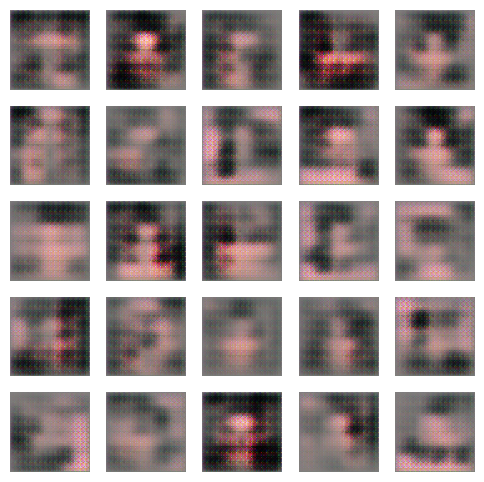

E:1, Loss G:1.8551, Loss D:0.5072, Acc G:%3.98, Acc D:%89.65
E:2, Loss G:1.3785, Loss D:0.5706, Acc G:%4.84, Acc D:%83.05
E:3, Loss G:1.6087, Loss D:0.5290, Acc G:%5.07, Acc D:%80.02
E:4, Loss G:1.8110, Loss D:0.5116, Acc G:%4.60, Acc D:%79.08
E:5, Loss G:1.6801, Loss D:0.5071, Acc G:%4.28, Acc D:%78.59


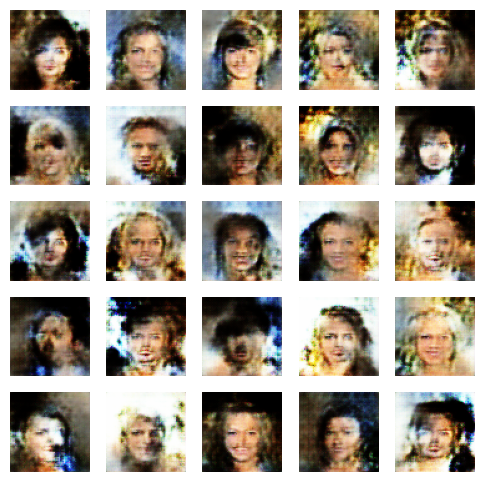

E:6, Loss G:1.6084, Loss D:0.5074, Acc G:%4.21, Acc D:%78.30
E:7, Loss G:1.6981, Loss D:0.4869, Acc G:%4.19, Acc D:%78.13
E:8, Loss G:1.7160, Loss D:0.4676, Acc G:%4.23, Acc D:%78.13
E:9, Loss G:1.6970, Loss D:0.4866, Acc G:%4.36, Acc D:%78.12
E:10, Loss G:1.6928, Loss D:0.4890, Acc G:%4.41, Acc D:%78.07


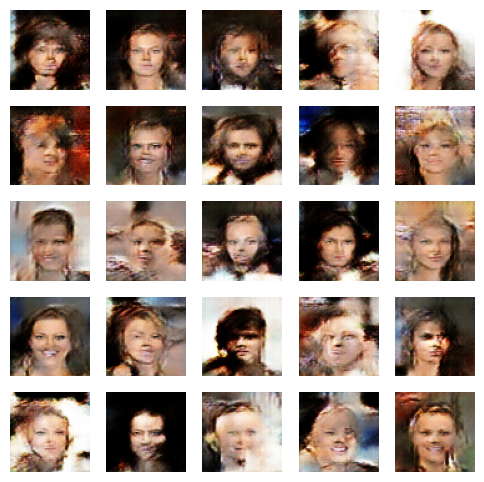

E:11, Loss G:1.6847, Loss D:0.4691, Acc G:%4.41, Acc D:%78.08
E:12, Loss G:1.6305, Loss D:0.4797, Acc G:%4.52, Acc D:%78.06
E:13, Loss G:1.6317, Loss D:0.4836, Acc G:%4.62, Acc D:%78.00
E:14, Loss G:1.6270, Loss D:0.4788, Acc G:%4.72, Acc D:%77.93
E:15, Loss G:1.6028, Loss D:0.4971, Acc G:%4.80, Acc D:%77.85


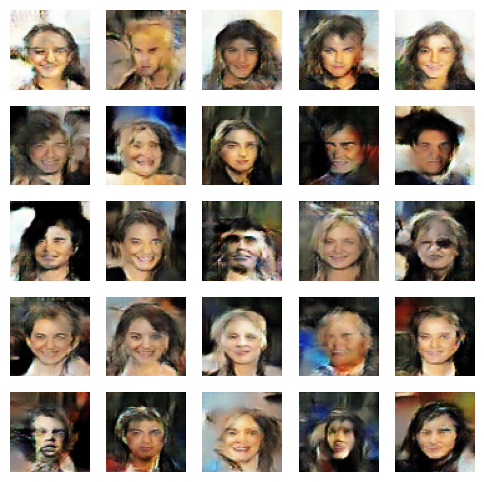

E:16, Loss G:1.5516, Loss D:0.4919, Acc G:%4.91, Acc D:%77.76
E:17, Loss G:1.5249, Loss D:0.4898, Acc G:%5.05, Acc D:%77.69
E:18, Loss G:1.5610, Loss D:0.4907, Acc G:%5.16, Acc D:%77.64
E:19, Loss G:1.4808, Loss D:0.5058, Acc G:%5.31, Acc D:%77.50
E:20, Loss G:1.5748, Loss D:0.4885, Acc G:%5.39, Acc D:%77.45


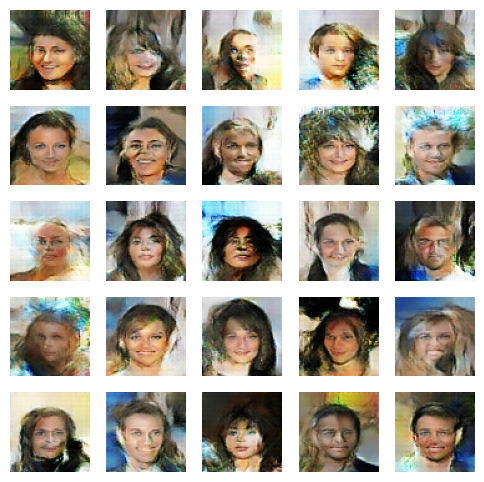

E:21, Loss G:1.5237, Loss D:0.4934, Acc G:%5.50, Acc D:%77.39
E:22, Loss G:1.4905, Loss D:0.5180, Acc G:%5.61, Acc D:%77.30
E:23, Loss G:1.5376, Loss D:0.4939, Acc G:%5.73, Acc D:%77.21
E:24, Loss G:1.5381, Loss D:0.4909, Acc G:%5.83, Acc D:%77.15
E:25, Loss G:1.5455, Loss D:0.4886, Acc G:%5.91, Acc D:%77.10


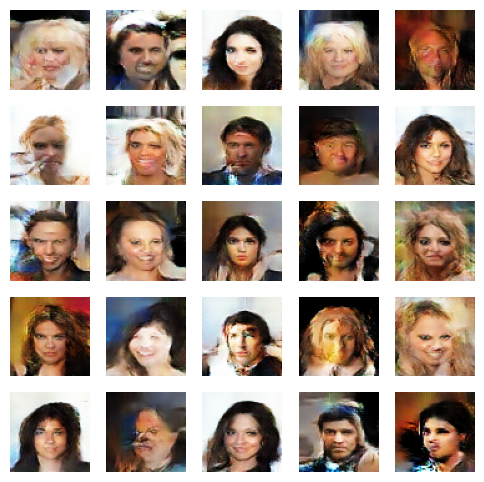

E:26, Loss G:1.5338, Loss D:0.4898, Acc G:%6.02, Acc D:%77.07
E:27, Loss G:1.5428, Loss D:0.5013, Acc G:%6.11, Acc D:%77.01
E:28, Loss G:1.5107, Loss D:0.5026, Acc G:%6.20, Acc D:%76.96
E:29, Loss G:1.5649, Loss D:0.4778, Acc G:%6.28, Acc D:%76.92
E:30, Loss G:1.5875, Loss D:0.4783, Acc G:%6.33, Acc D:%76.92


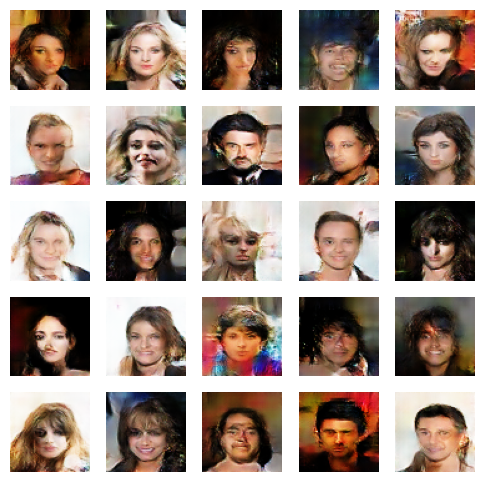

E:31, Loss G:1.5035, Loss D:0.4974, Acc G:%6.41, Acc D:%76.91
E:32, Loss G:1.5617, Loss D:0.4957, Acc G:%6.51, Acc D:%76.86
E:33, Loss G:1.5687, Loss D:0.4756, Acc G:%6.58, Acc D:%76.84
E:34, Loss G:1.5804, Loss D:0.4700, Acc G:%6.62, Acc D:%76.86
E:35, Loss G:1.5884, Loss D:0.4720, Acc G:%6.69, Acc D:%76.87


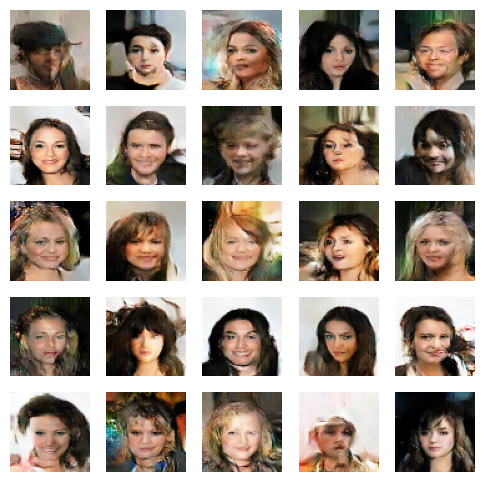

E:36, Loss G:1.6239, Loss D:0.4741, Acc G:%6.74, Acc D:%76.89
E:37, Loss G:1.4758, Loss D:0.5539, Acc G:%6.85, Acc D:%76.83
E:38, Loss G:1.5829, Loss D:0.4574, Acc G:%6.93, Acc D:%76.80
E:39, Loss G:1.6389, Loss D:0.4646, Acc G:%6.96, Acc D:%76.85
E:40, Loss G:1.6295, Loss D:0.4471, Acc G:%7.01, Acc D:%76.87


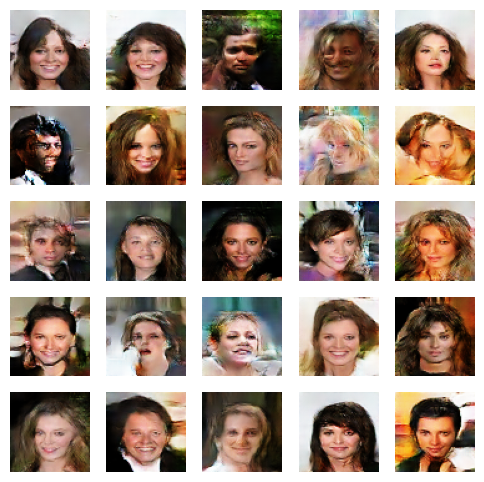

E:41, Loss G:1.6566, Loss D:0.4628, Acc G:%7.05, Acc D:%76.92
E:42, Loss G:1.6734, Loss D:0.4605, Acc G:%7.09, Acc D:%76.95
E:43, Loss G:1.6797, Loss D:0.4336, Acc G:%7.13, Acc D:%77.00
E:44, Loss G:1.7256, Loss D:0.4262, Acc G:%7.17, Acc D:%77.07
E:45, Loss G:1.7587, Loss D:0.4314, Acc G:%7.19, Acc D:%77.15


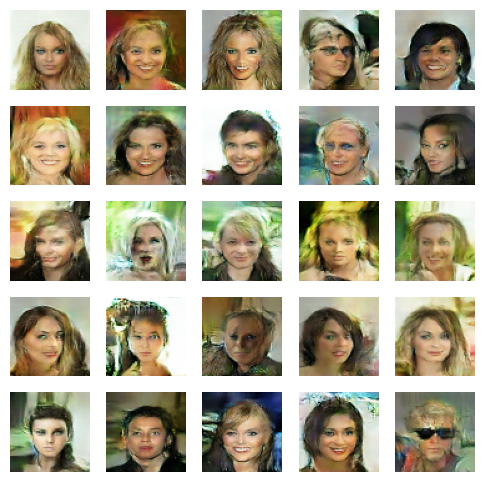

E:46, Loss G:1.7739, Loss D:0.4201, Acc G:%7.22, Acc D:%77.21
E:47, Loss G:1.7756, Loss D:0.4166, Acc G:%7.25, Acc D:%77.29
E:48, Loss G:1.8039, Loss D:0.4199, Acc G:%7.28, Acc D:%77.36
E:49, Loss G:1.8370, Loss D:0.6149, Acc G:%7.31, Acc D:%77.43
E:50, Loss G:1.2678, Loss D:0.5797, Acc G:%7.52, Acc D:%77.29


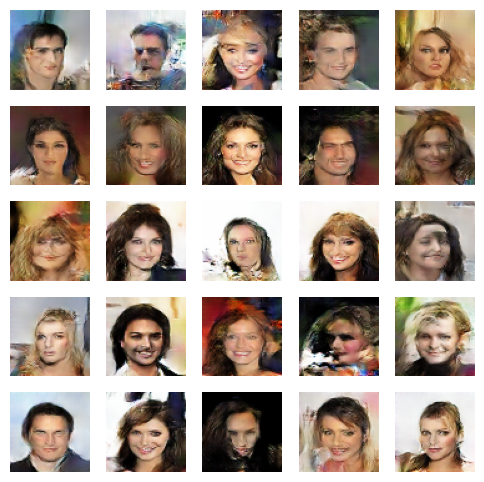

E:51, Loss G:1.6071, Loss D:0.4366, Acc G:%7.61, Acc D:%77.26
E:52, Loss G:1.6850, Loss D:0.4009, Acc G:%7.63, Acc D:%77.34
E:53, Loss G:1.7582, Loss D:0.3953, Acc G:%7.64, Acc D:%77.43
E:54, Loss G:1.8347, Loss D:0.3863, Acc G:%7.65, Acc D:%77.53
E:55, Loss G:1.8474, Loss D:0.3968, Acc G:%7.67, Acc D:%77.62


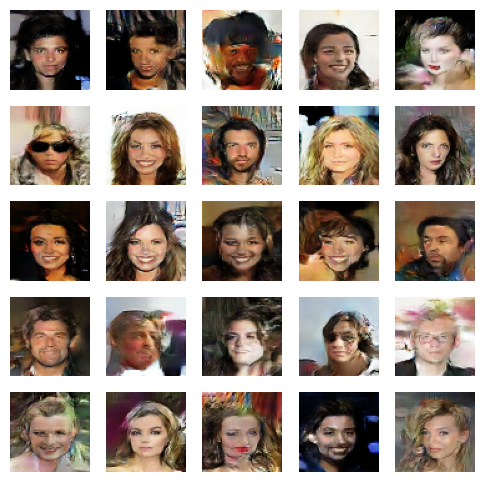

E:56, Loss G:1.8702, Loss D:0.3915, Acc G:%7.69, Acc D:%77.71
E:57, Loss G:1.8503, Loss D:0.4054, Acc G:%7.71, Acc D:%77.78
E:58, Loss G:1.9344, Loss D:0.3728, Acc G:%7.73, Acc D:%77.88
E:59, Loss G:1.7375, Loss D:0.5727, Acc G:%7.77, Acc D:%77.94


In [15]:
EPOCHS = 60
# treinando o gerador 2 vezes em um epoca e o descriminador 1

for epoch in range(EPOCHS):
  dLossSum = 0
  gLossSum = 0
  dAccSum = 0
  gAccSum = 0
  cnt = 0

  for batch in df:
    dLoss = trainDStep(batch)
    dLossSum += dLoss['discriminator_loss']
    dAccSum += dLoss['discriminator_accuracy']

    gLoss = trainGStep(batch)
    gLossSum += gLoss['generator_loss']
    gAccSum += gLoss['generator_accuracy']

    cnt += 1

  print("E:{}, Loss G:{:0.4f}, Loss D:{:0.4f}, Acc G:%{:0.2f}, Acc D:%{:0.2f}".format(
      epoch, gLossSum/cnt, dLossSum/cnt, 100*gAccSum/cnt, 100*dAccSum/cnt
  ))

  if epoch % 5 == 0:
    plot(gerador)

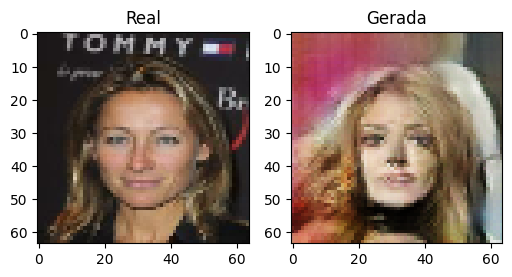

In [18]:
# pega uma imagem real do dataset
for batch in df.take(1):
    imagem_real = batch[1]  # primeira imagem do primeiro batch
    break

imagem_real = (imagem_real.numpy() + 1) / 2  # desfaz normalização -1 a 1 para 0 - 1

# gera uma imagem sintética
noise = np.random.normal(size=(1, NOISE_DIM))
imagem_gerada = gerador(noise)
imagem_gerada = (imagem_gerada[0].numpy() + 1) / 2

# plot lado a lado
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(imagem_real)
plt.title("Real")

plt.subplot(1,2,2)
plt.imshow(imagem_gerada)
plt.title("Gerada")

plt.show()